<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [1]:
!pip install datasets

Импорт необходимых библиотек

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [5]:
# Загрузим датасет
dataset = load_dataset('imdb')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [6]:
from tqdm import tqdm

sentences = []
word_threshold = 32

for sentence in tqdm(dataset['train']['text']):
    sentences.extend(
        [x.lower() for x in sent_tokenize(sentence, language='english')]
        )

sentences_token = []
for sentence in tqdm(sentences):
    token = word_tokenize(sentence, language='english', preserve_line=True)
    if len(token) < word_threshold:
        sentences_token.append(token)



100%|██████████| 271057/271057 [00:21<00:00, 12659.88it/s]


In [7]:
print("Всего предложений:", len(sentences_token))

Всего предложений: 198802


In [8]:
sentences_token[4]

['but',
 'really',
 ',',
 'this',
 'film',
 'does',
 "n't",
 'have',
 'much',
 'of',
 'a',
 'plot',
 '.']

Посчитаем для каждого слова его встречаемость.

In [9]:
words = Counter()

for sentence in tqdm(sentences_token):
    for word in sentence:
        words[word] += 1

100%|██████████| 198802/198802 [00:01<00:00, 194534.65it/s]


In [10]:
print(len(words))

68426


Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [11]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 40000

most_common_words = words.most_common(vocab_size)
for word, cnt in most_common_words:
      vocab.add(word)

In [12]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [13]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [14]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [15]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(char, self.unk_id) for char in self.data[idx]]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [16]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [17]:
train_sentences, temp_sentences = train_test_split(sentences_token, test_size=0.2)
eval_sentences, test_sentences = train_test_split(temp_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size,
    shuffle=True)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [18]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    total_loss = 0
    total_tokens = 0
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            non_pad = (batch['target_ids'] != word2ind['<pad>']).sum().item()
            total_loss += loss.item() * non_pad
            total_tokens += non_pad

    mean_loss = total_loss / total_tokens
    perplexity = np.exp(mean_loss)
    return perplexity

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [19]:
def train_model(model, optimizer, criterion, num_epoch=10):
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))
    return (losses, perplexities)

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [20]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim,
                                      padding_idx=word2ind['<pad>'])
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        # Опишите свою нейронную сеть здесь

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [48]:
model = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [51]:
losses, perplexities = train_model(model, optimizer, criterion)

Training epoch 9:: 100%|██████████| 1243/1243 [02:19<00:00,  8.94it/s]


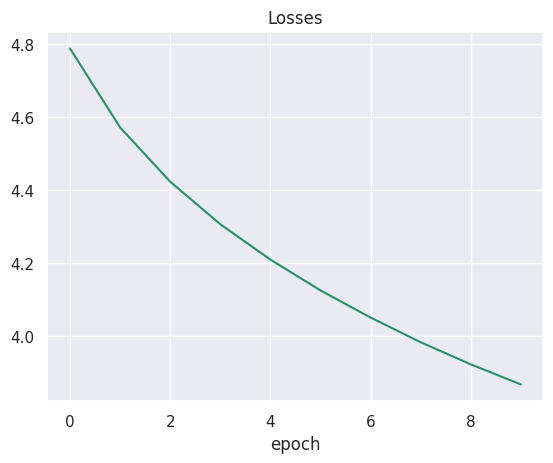

In [52]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

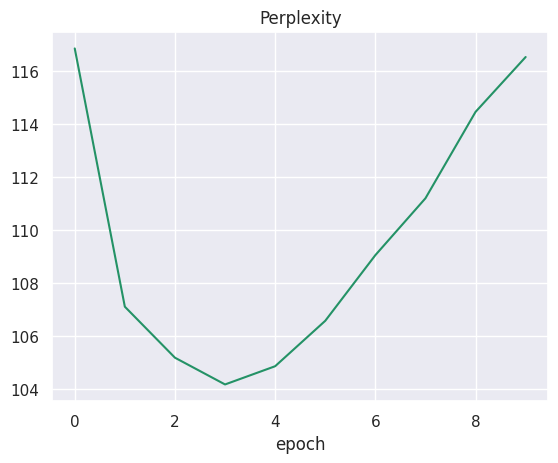

In [53]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [58]:
model2 = LanguageModel(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion2 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer2 = torch.optim.Adam(model2.parameters())

In [59]:
losses2, perplexities2 = train_model(model2, optimizer2, criterion2)

Training epoch 9:: 100%|██████████| 1243/1243 [01:31<00:00, 13.55it/s]


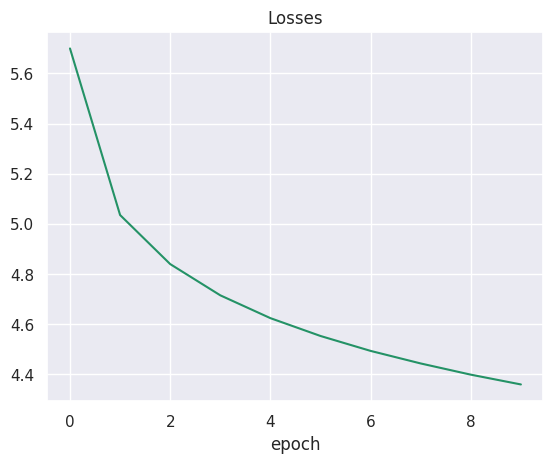

In [60]:
plt.plot(np.arange(len(losses2)), losses2)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

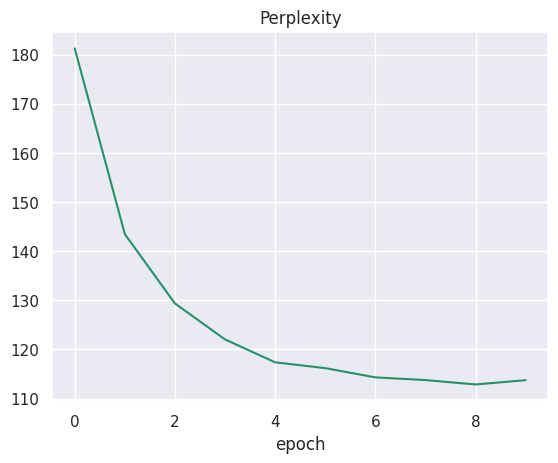

In [61]:
plt.plot(np.arange(len(perplexities2)), perplexities2)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [22]:
class LanguageModel2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim,
                                      padding_idx=word2ind['<pad>'])
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True,
                          num_layers=2,
                          dropout=0.2)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        # Опишите свою нейронную сеть здесь

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [23]:
model3 = LanguageModel2(hidden_dim=128, vocab_size=len(vocab)).to(device)
criterion3 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer3 = torch.optim.Adam(model3.parameters())

In [24]:
losses3, perplexities3 = train_model(model3, optimizer3, criterion3)

Training epoch 9:: 100%|██████████| 1243/1243 [01:36<00:00, 12.95it/s]


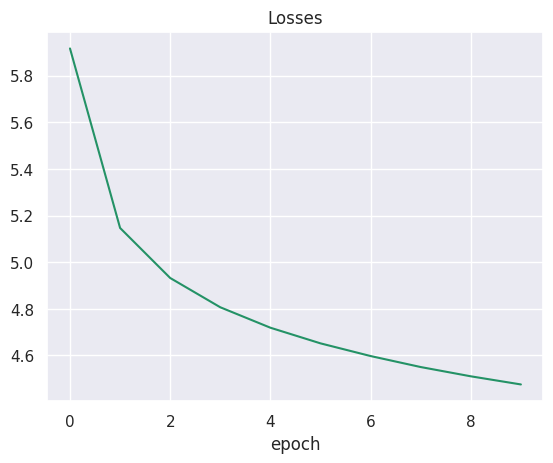

In [25]:
plt.plot(np.arange(len(losses3)), losses3)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

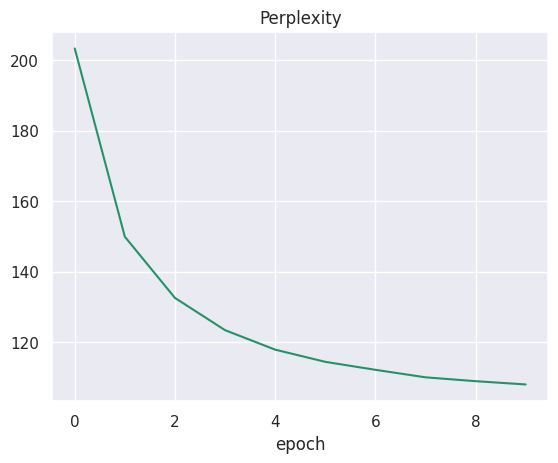

In [26]:
plt.plot(np.arange(len(perplexities3)), perplexities3)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [27]:
class LanguageModel3(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim,
                                      padding_idx=word2ind['<pad>'])
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.3)
        # Опишите свою нейронную сеть здесь

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [29]:
model4 = LanguageModel3(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion4 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer4 = torch.optim.Adam(model4.parameters())

In [30]:
losses4, perplexities4 = train_model(model4, optimizer4, criterion4)

Training epoch 9:: 100%|██████████| 1243/1243 [02:22<00:00,  8.75it/s]


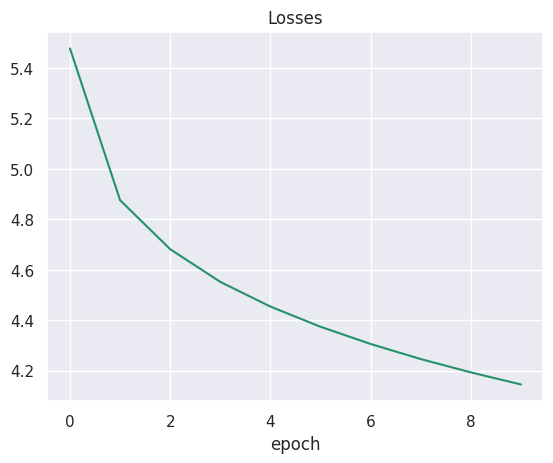

In [31]:
plt.plot(np.arange(len(losses4)), losses4)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

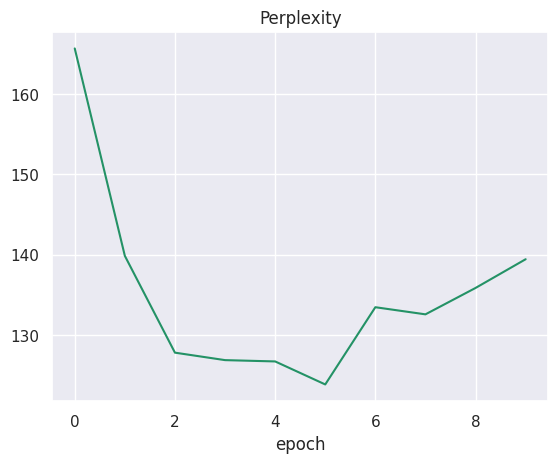

In [32]:
plt.plot(np.arange(len(perplexities4)), perplexities4)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [33]:
model5 = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion5 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer5 = torch.optim.Adam(model5.parameters(), lr=3e-4)

In [34]:
losses5, perplexities5 = train_model(model5, optimizer5, criterion5)

Training epoch 9:: 100%|██████████| 1243/1243 [02:22<00:00,  8.71it/s]


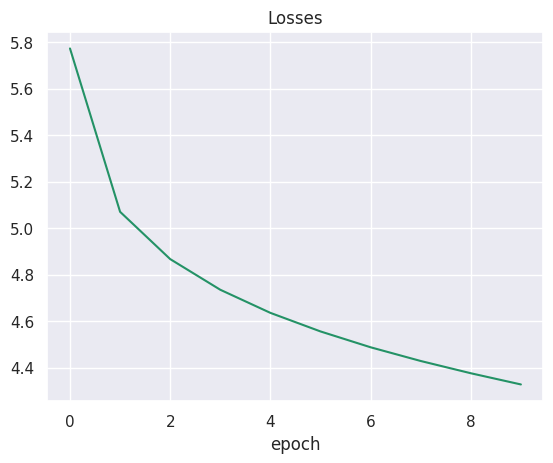

In [35]:
plt.plot(np.arange(len(losses5)), losses5)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

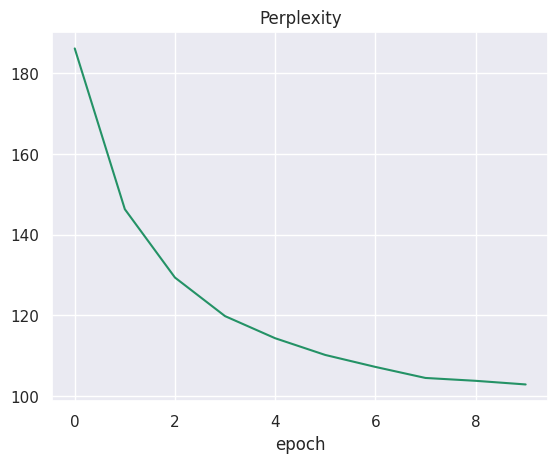

In [36]:
plt.plot(np.arange(len(perplexities5)), perplexities5)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [40]:
class LanguageModel4(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim,
                                      padding_idx=word2ind['<pad>'])
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)
        # Опишите свою нейронную сеть здесь

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [41]:
model6 = LanguageModel4(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion6 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer6 = torch.optim.Adam(model6.parameters())

In [42]:
losses6, perplexities6 = train_model(model6, optimizer6, criterion6)

Training epoch 9:: 100%|██████████| 1243/1243 [02:23<00:00,  8.64it/s]


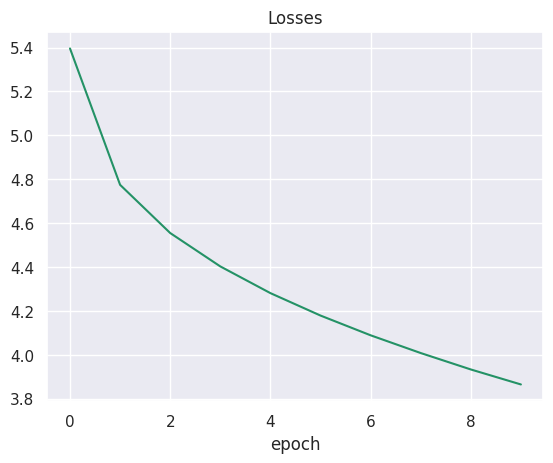

In [43]:
plt.plot(np.arange(len(losses6)), losses6)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

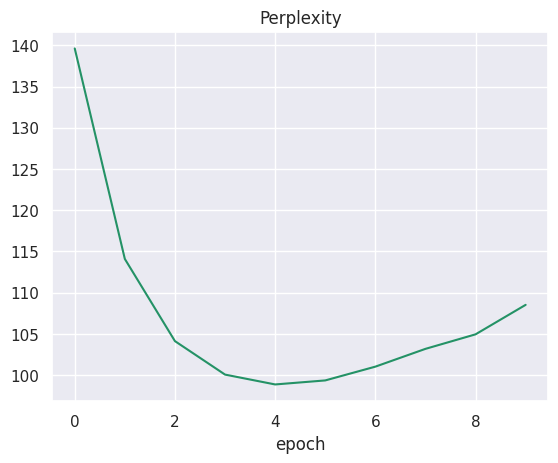

In [44]:
plt.plot(np.arange(len(perplexities6)), perplexities6)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [45]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 20) -> str:
    device = 'cpu'
    model = model.to(device)
    input_ids = [word2ind['<bos>']] + [
        word2ind.get(char, word2ind['<unk>']) for char in starting_seq]
    input_ids = torch.LongTensor(input_ids).to(device)

    model.eval()
    with torch.no_grad():
        for i in range(max_seq_len):
            next_char_distribution = model(input_ids)[-1]
            next_char = next_char_distribution.squeeze().argmax()
            input_ids = torch.cat([input_ids, next_char.unsqueeze(0)])

            if next_char.item() == word2ind['<eos>']:
                break

    words = ''.join([ind2word[idx.item()] for idx in input_ids])

    return words

In [53]:
generate_sequence(model5, starting_seq=['scenario', 'was', 'good', ',','but'])

"<bos>scenariowasgood,butit'snotabadmovie.<eos>"

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

В данной работе была реализована языковая модель на уровне слов для датасета IMDb. Тексты были разбиты на предложения, затем предложения токенизированы, после чего был построен словарь наиболее частотных слов со специальными токенами \<unk>, \<bos>, \<eos> и \<pad>. Для обучения использовалась рекуррентная нейросеть с Embedding, RNN-блоком, линейными слоями и финальной проекцией в пространство словаря.

В качестве основной метрики использовалась perplexity. В ходе экспериментов было замечено, что training loss стабильно уменьшается, однако validation perplexity после нескольких эпох перестает улучшаться и начинает расти. Это говорит о появлении переобучения, поэтому лучшей следует считать не последнюю эпоху, а ту, на которой достигается минимальная perplexity на валидации.

В качестве базовой модели была рассмотрена однослойная GRU с hidden_dim = 256. Также были проведены эксперименты с уменьшением скрытого размера до 128, добавлением второго GRU-слоя, увеличением dropout и заменой GRU на LSTM. Уменьшение hidden_dim ухудшило качество, так как модель стала менее выразительной. Добавление второго слоя не дало заметного улучшения: кривые loss и perplexity остались почти такими же. Увеличение dropout оказалось полезным как способ борьбы с переобучением. Замена GRU на LSTM не привела к существенному выигрышу, и качество осталось сопоставимым.

Таким образом, наибольшее влияние на результат в данной задаче оказали емкость модели и регуляризация, а не просто увеличение глубины рекуррентной части. Для дальнейшего улучшения качества можно использовать early stopping, более тщательный подбор гиперпараметров и более продвинутую токенизацию, например subword-подход.